In [9]:
from mpasviewer import scvtmesh
from earthcmap import escmap
import cartopy.crs as ccrs

In [2]:
path2data = 'sample_data'

mpasd = scvtmesh(grid_file=f'{path2data}/MPAS-O_V6.0_EC60to30/oEC60to30v3_60layer.170905.nc', 
                 diag_list=f'{path2data}/MPAS-O_V6.0_EC60to30/forcing_data.nc')

In [ ]:
mpasd.dataset()

In [4]:
dta = mpasd.load()

In [5]:
dta

<xarray.Dataset> Size: 47MB
Dimensions:                           (node: 478835, edge: 714274,
                                       face: 235160, time: 1, nmax_face: 7)
Coordinates:
    node_x                            (node) float64 4MB 130.7 142.6 ... -16.26
    node_y                            (node) float64 4MB 73.03 76.42 ... 68.24
    edge_x                            (edge) float64 6MB -30.92 113.0 ... 112.8
    edge_y                            (edge) float64 6MB -45.54 7.159 ... -4.953
    face_x                            (face) float64 2MB -174.7 129.0 ... 144.0
    face_y                            (face) float64 2MB 62.2 18.47 ... 11.8
  * time                              (time) datetime64[s] 8B 1970-01-01
Dimensions without coordinates: node, edge, face, nmax_face
Data variables:
    mesh2d                            int64 8B 0
    projected_coordinate_system       int64 8B 0
    face_nodes                        (face, nmax_face) int64 13MB 18429 ... -1
    windStressZonal                   (time, face) float64 2MB -0.08501 ... -...
    windStressMeridional              (time, face) float64 2MB -0.06858 ... -...
    temperaturePistonVelocity         (time, face) float64 2MB 5e-05 ... 5e-05
    salinityPistonVelocity            (time, face) float64 2MB 5e-05 ... 5e-05
    temperatureSurfaceRestoringValue  (time, face) float64 2MB -1.348 ... 27.84
    salinitySurfaceRestoringValue     (time, face) float64 2MB 31.93 ... 34.4
Attributes:
    Conventions:      CF-1.12 UGRID-1.0
    model_name:       MPAS
    core_name:        Atmosphere
    source:           MPAS-A
    source_software:  MPAS-viewer
    date_created:     2026-02-20 00:03:32Z
    date_modified:    2026-02-20 00:03:32Z

In [6]:
times = [str(x) for x in dta['time'].data.astype('datetime64[s]')]
# print(*times, sep = ", ")

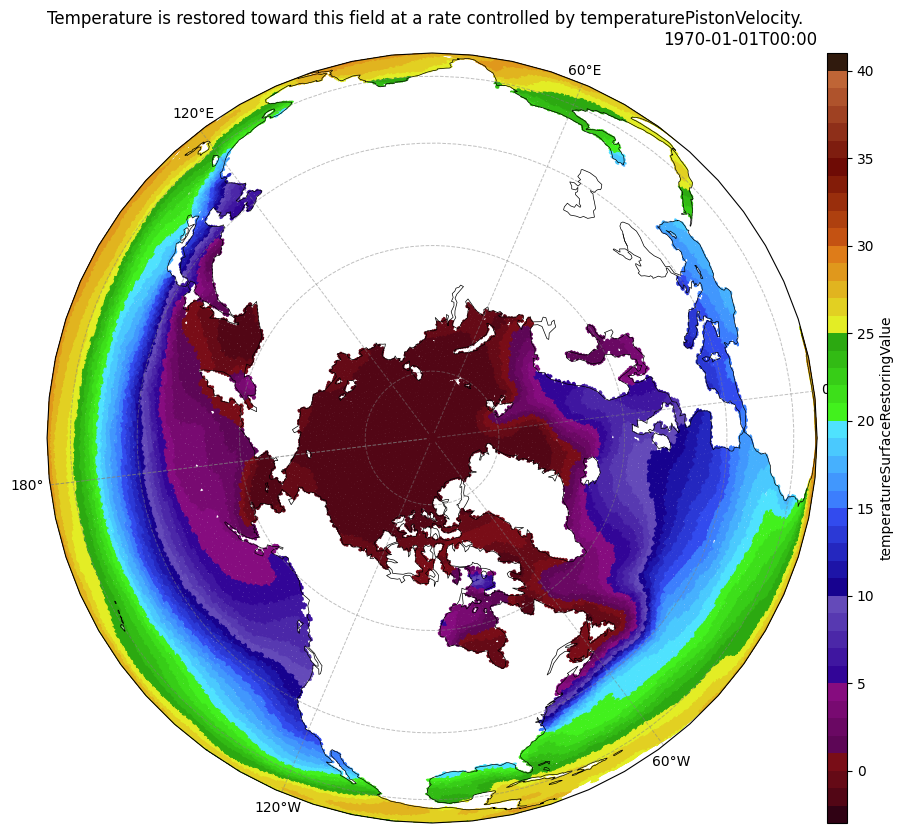

In [10]:
var1 = 'temperatureSurfaceRestoringValue'
cmap, norm = escmap("noaa_sst", units=dta[var1].attrs['units'])
mpasd.show(dta, var_name = var1, crs=ccrs.Orthographic(central_longitude=-97, central_latitude=90), cmap = cmap, norm = norm, figsize = (10, 10))